In [0]:
%%capture
!pip install pymc

!pip install --upgrade databricks-langchain langchain-community langchain langchainhub langgraph databricks-sql-connector tiktoken streamlit faiss-cpu google-ai-generativelanguage langchain-google-genai

dbutils.library.restartPython()

In [0]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [0]:
import pymc as pm
import pandas as pd
import numpy as np
import re
import os
import random
import json
import matplotlib.pyplot as plt
import time

from scipy.stats import gaussian_kde

In [0]:
from databricks_langchain import ChatDatabricks
from databricks_langchain import DatabricksEmbeddings
from langchain.schema.output_parser import StrOutputParser
from typing_extensions import Annotated,TypedDict


from langgraph.graph import START, StateGraph
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent
from langchain.schema.runnable import RunnableMap
from langchain.prompts import PromptTemplate
from langchain.agents import initialize_agent, Tool
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langchain.tools import Tool
from langgraph.prebuilt import tools_condition

from langchain_google_genai import ChatGoogleGenerativeAI

from pydantic import BaseModel, Field, ValidationError
from typing import List, Union
import numpy as np
from langchain.prompts import ChatPromptTemplate
import json
import rich
import pprint
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

from IPython.display import Image, display

In [0]:
# Milkbot Prediction Function

def milk_yield_prediction_from_milkbot(parity='1', region="Europe", dim_range=np.arange(1, 306, 1)):
    parity = str(parity)

    if region == "Europe":
        if parity == '1':
            scale_p, ramp_p, decay_p, offset_p = 27.3, 30.7, 0.0028, -0.084
        elif parity == '2':
            scale_p, ramp_p, decay_p, offset_p = 34.3, 22.8, 0.00276, -0.775
        else:
            scale_p, ramp_p, decay_p, offset_p = 41.8, 26.4, 0.00359, 0.00397
    elif region == "United States":
        if parity == '1':
            scale_p, ramp_p, decay_p, offset_p = 38.3, 30.72, 0.0022, -0.499
        elif parity == '2':
            scale_p, ramp_p, decay_p, offset_p = 48.2, 22.8, 0.0029, -0.775
        else:
            scale_p, ramp_p, decay_p, offset_p = 53.5, 25.5, 0.00309, 0.0039
    else:
        raise ValueError("Invalid region specified. Choose 'Europe' or 'United States'.")

    my_prediction = []

    for dim in dim_range:
        milk_yield = scale_p * np.exp(-decay_p * dim) * (1 - np.exp((offset_p - dim) / ramp_p) / 2)
        my_prediction.append(milk_yield)

    return dim_range, my_prediction



def predict_milk_yield_for_region(region= ['Europe','United States'], parity = ['1','2','3+'], dim_range=np.arange(1,306,1)):
    
    europe_pattern = r"\b(eu|europe|eu region|european)\b"
    us_pattern = r"\b(us|united states|usa|american)\b"
    response =[]

    for r in region:
        if re.search(europe_pattern, r.lower()):
            for p in parity:
                dim_range, my_prediction = milk_yield_prediction_from_milkbot(p, region='Europe', dim_range=dim_range)
                response.append({'region': 'Europe', "parity": p, "dim_range": dim_range, "my_prediction": my_prediction})

        elif re.search(us_pattern, r.lower()):
            for p in parity:
                dim_range, my_prediction = milk_yield_prediction_from_milkbot(p, region='United States', dim_range=dim_range)
                response.append({'region': 'United States', "parity": p, "dim_range": dim_range, "my_prediction": my_prediction})

        else:
            print(f'Error: Current model only covers regions of Europe and United States. Invalid region: {r}')
    
    
    return response


# Visuals Generation Function

def get_region_colors(region, num_parities):
    region_colormap = {
        'Europe': plt.cm.Blues, # Different region have different colors
        'United States': plt.cm.Reds
    }
    
    cmap = region_colormap.get(region, plt.cm.Greys)  # Default to Greys if region not specified
    return cmap(np.linspace(0.4, 0.9, num_parities))



def milk_yield_plot(response):

    region_parity_map = {}
    
    # Collect regions and their parities
    for item in response:
        region = item['region']
        if region not in region_parity_map:
            region_parity_map[region] = []
        region_parity_map[region].append(item['parity'])

    # Generate colors for each region-parity combination
    region_colors = {}
    for region, parities in region_parity_map.items():
        unique_parities = list(set(parities))
        region_colors[region] = get_region_colors(region, len(unique_parities))

    if len(response[0]['dim_range'])>20:

        plt.figure(figsize=(8, 4))
        
        for item in response:
            region = item['region']
            parity = item['parity']
            dim_range = item['dim_range']
            milk_predictions = item['my_prediction']

            # Assign appropriate color based on region and parity
            parity_index = list(set(region_parity_map[region])).index(parity)
            plt.plot(dim_range, milk_predictions,
                     label=f'Predicted Milk - Parity {parity} in {region}',
                     color=region_colors[region][parity_index])

        plt.title('Predicted Milk Yield vs Days in Milk')
        plt.xlabel('Days in Milk')
        plt.ylabel('Milk Yield (Kg)')
        plt.legend(fontsize= 8,loc='upper right')
        plt.grid(False)
        plt.show()

    else:
        plt.figure(figsize=(8, 4))
        
        for item in response:
            region = item['region']
            parity = item['parity']
            dim_range = item['dim_range']
            milk_predictions = item['my_prediction']

            # Assign color for scatter plot
            parity_index = list(set(region_parity_map[region])).index(parity)
            plt.scatter(dim_range, milk_predictions,
                        label=f'Predicted Milk - Parity {parity} in {region}',
                        color=region_colors[region][parity_index], s=10)

            # Annotate each dot
            for x, y in zip(dim_range, milk_predictions):
                plt.annotate(f'{float(y):.2f}', (x, y), textcoords="offset points", xytext=(5, 5), ha='center')

        plt.title('Predicted Milk Yield vs Days in Milk')
        plt.xlabel('Days in Milk')
        plt.ylabel('Milk Yield (Kg)')
        plt.legend(fontsize= 8, loc='upper right')
        plt.grid(False)
        plt.show()


# Final MilkBot_Visuals Function, which integrate all above functions
def milkbot_prediction_visuals(region=['eu','us'], parity = ['1','2','3+'], dim_range=np.arange(1,306,1)):
    response = predict_milk_yield_for_region(region, parity, dim_range)
    return milk_yield_plot(response)

In [0]:
llama70b = ChatDatabricks(
    endpoint="databricks-meta-llama-3-1-70b-instruct",
    temperature=0.0,
    max_tokens=1024,
)

llm=llama70b

In [0]:
# Process user question to extract key parameters to input the MilkBot model
class extraction(BaseModel):
    region: list[str] = Field(default_factory=lambda:['eu'])
    parity: list[str] = Field(default_factory=lambda:['1', '2', '3+'])
    dim_range: List[int] = Field(default_factory=lambda:list(np.arange(1, 306, 1)))

llm.with_structured_output(extraction)

def prepare_query_for_milk_yield_visuals(state):
    """
    This function prepares the query for milk yield visuals.
    Args:
        state (messages): The current state
    Returns:
        dic: A dict containing the extracted parameters
    """

    print('---EXTRACTING KEY INFORMATION FROM QUESTION---')
    time.sleep(2)
    print('\n')
    print('---GENERATING VISUALS FROM EXTRACTED INFORMATION---')

    query=state['messages'][0].content

    prompt = """
    Extract the following parameters from the user's query:

    1. Region (e.g., US, Europe): If the region is mentioned, extract it. If not specified, default to ['eu'].
    2. Parity (number indicating parity): Extract parity if explicitly mentioned (e.g., parity 1). If not specified, default to ['1','2','3+'].
    3. DIM range (list format): Extract if specified as a range or list. If not, default to np.arange(1, 306, 1).

    User Query: "{query}"

    Return ONLY the extracted parameters in strict JSON format without any additional text or explanations. 
    Ensure the format follows this example:
    {{"region":["US"],"parity":["1"],"dim_range":[1, 2, 3, ..., 305]}}
    """
    
    extraction_prompt = ChatPromptTemplate.from_template(prompt)
    
    chain = extraction_prompt | llm
    response = chain.invoke(query)
    state["messages"].append(response)

    # print(response.content)
    
    return {"messages": state['messages']}

    # query_output = response.content

    # return query_output

In [0]:
def milkbot_visuals(state):
    """
    Invokes the milkbot model to generate a response based on the current state. It will produce the prediction and visuals
    
    Args:
        state (messages): The current state
    
    Returns:
        dict: The updated state with the agent response appended to messages
    """


    # print(state["messages"][-1].content, type(state["messages"][-1].content))

    # message = json.loads(query_output)
    message = json.loads(state['messages'][-1].content)

    region_ai= message['region']
    parity_ai= message['parity']
    dim_range_ai= message['dim_range']

    # print(region_ai)
    
    return milkbot_prediction_visuals(region= region_ai, parity= parity_ai, dim_range= dim_range_ai)

    # response = HumanMessage(content=f"--- \nHere are the graphs generated by **__Visuals@MilkBot__** for your query: \n{state['messages'][0].content} \n---")

    # state['messages'].append(response)

    # # print(response.content)

    # return {"messages": state['messages']}


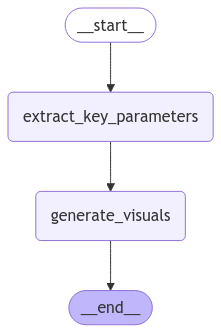

In [0]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes before inference
workflow.add_node("extract_key_parameters", prepare_query_for_milk_yield_visuals)
workflow.add_node("generate_visuals", milkbot_visuals)

# Connect agent nodes
workflow.add_edge(START, "extract_key_parameters")
workflow.add_edge('extract_key_parameters', 'generate_visuals')
workflow.add_edge('generate_visuals', END)

# Compile
graph = workflow.compile()

# Display graph
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

---EXTRACTING KEY INFORMATION FROM QUESTION---


---GENERATING VISUALS FROM EXTRACTED INFORMATION---


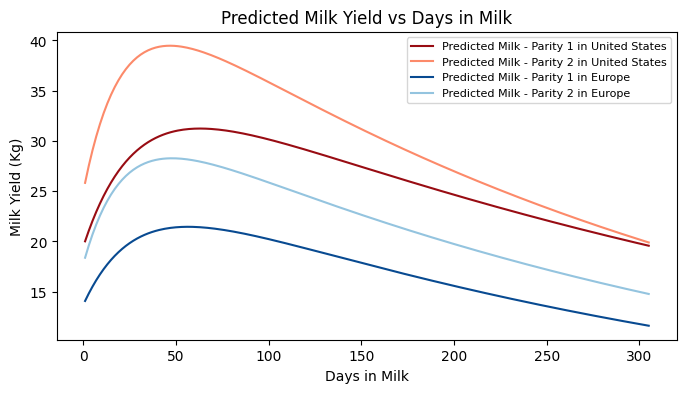

{'messages': [HumanMessage(content='milk yield for parity 1 and 2 us and eu cows', additional_kwargs={}, response_metadata={}, id='7bec67eb-6790-423a-a641-519a3c4aa542'),
  AIMessage(content='{"region":["US", "EU"],"parity":["1","2"],"dim_range":[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 1

Trace(request_id=tr-dfbe92c57b754d7dbfdd3b09d098bf94)

In [0]:
input_example = {
    "messages": [
        {
            "role": "user",
            "content": "milk yield for parity 1 and 2 us and eu cows"
        }
    ]
}

graph.invoke(input_example)

In [0]:
%%writefile milkbot_visuals.py
# omit this line if directly creating this file; this command is purely for running within Jupyter

import pymc as pm
import pandas as pd
import numpy as np
import re
import os
import random
import json
import matplotlib.pyplot as plt
import time
from scipy.stats import gaussian_kde

from databricks_langchain import ChatDatabricks
from databricks_langchain import DatabricksEmbeddings
from typing_extensions import Annotated,TypedDict
from langchain.schema.runnable import RunnableMap
from langchain.prompts import PromptTemplate
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate
from langgraph.graph.message import add_messages
from langgraph.graph import END, StateGraph, START

from pydantic import BaseModel, Field, ValidationError
from typing import List, Union
from langchain.prompts import ChatPromptTemplate
import rich

import mlflow

# Milkbot Prediction Function

os.environ["DATABRICKS_HOST"] = "xxxxx"
os.environ["DATABRICKS_TOKEN"] = "xxxxx"

def milk_yield_prediction_from_milkbot(parity='1', region="Europe", dim_range=np.arange(1, 306, 1)):
    parity = str(parity)

    if region == "Europe":
        if parity == '1':
            scale_p, ramp_p, decay_p, offset_p = 27.3, 30.7, 0.0028, -0.084
        elif parity == '2':
            scale_p, ramp_p, decay_p, offset_p = 34.3, 22.8, 0.00276, -0.775
        else:
            scale_p, ramp_p, decay_p, offset_p = 41.8, 26.4, 0.00359, 0.00397
    elif region == "United States":
        if parity == '1':
            scale_p, ramp_p, decay_p, offset_p = 38.3, 30.72, 0.0022, -0.499
        elif parity == '2':
            scale_p, ramp_p, decay_p, offset_p = 48.2, 22.8, 0.0029, -0.775
        else:
            scale_p, ramp_p, decay_p, offset_p = 53.5, 25.5, 0.00309, 0.0039
    else:
        raise ValueError("Invalid region specified. Choose 'Europe' or 'United States'.")

    my_prediction = []

    for dim in dim_range:
        milk_yield = scale_p * np.exp(-decay_p * dim) * (1 - np.exp((offset_p - dim) / ramp_p) / 2)
        my_prediction.append(milk_yield)

    return dim_range, my_prediction



def predict_milk_yield_for_region(region= ['Europe','United States'], parity = ['1','2','3+'], dim_range=np.arange(1,306,1)):
    
    europe_pattern = r"\b(eu|europe|eu region|european)\b"
    us_pattern = r"\b(us|united states|usa|american)\b"
    response =[]

    for r in region:
        if re.search(europe_pattern, r.lower()):
            for p in parity:
                dim_range, my_prediction = milk_yield_prediction_from_milkbot(p, region='Europe', dim_range=dim_range)
                response.append({'region': 'Europe', "parity": p, "dim_range": dim_range, "my_prediction": my_prediction})

        elif re.search(us_pattern, r.lower()):
            for p in parity:
                dim_range, my_prediction = milk_yield_prediction_from_milkbot(p, region='United States', dim_range=dim_range)
                response.append({'region': 'United States', "parity": p, "dim_range": dim_range, "my_prediction": my_prediction})

        else:
            print(f'Error: Current model only covers regions of Europe and United States. Invalid region: {r}')
    
    
    return response


# Visuals Generation Function

def get_region_colors(region, num_parities):
    region_colormap = {
        'Europe': plt.cm.Blues, # Different region have different colors
        'United States': plt.cm.Reds
    }
    
    cmap = region_colormap.get(region, plt.cm.Greys)  # Default to Greys if region not specified
    return cmap(np.linspace(0.4, 0.9, num_parities))



def milk_yield_plot(response):

    region_parity_map = {}
    
    # Collect regions and their parities
    for item in response:
        region = item['region']
        if region not in region_parity_map:
            region_parity_map[region] = []
        region_parity_map[region].append(item['parity'])

    # Generate colors for each region-parity combination
    region_colors = {}
    for region, parities in region_parity_map.items():
        unique_parities = list(set(parities))
        region_colors[region] = get_region_colors(region, len(unique_parities))

    if len(response[0]['dim_range'])>20:

        plt.figure(figsize=(8, 4))
        
        for item in response:
            region = item['region']
            parity = item['parity']
            dim_range = item['dim_range']
            milk_predictions = item['my_prediction']

            # Assign appropriate color based on region and parity
            parity_index = list(set(region_parity_map[region])).index(parity)
            plt.plot(dim_range, milk_predictions,
                     label=f'Predicted Milk - Parity {parity} in {region}',
                     color=region_colors[region][parity_index])

        plt.title('Predicted Milk Yield vs Days in Milk')
        plt.xlabel('Days in Milk')
        plt.ylabel('Milk Yield (Kg)')
        plt.legend(fontsize= 8,loc='upper right')
        plt.grid(False)
        plt.show()

    else:
        plt.figure(figsize=(8, 4))
        
        for item in response:
            region = item['region']
            parity = item['parity']
            dim_range = item['dim_range']
            milk_predictions = item['my_prediction']

            # Assign color for scatter plot
            parity_index = list(set(region_parity_map[region])).index(parity)
            plt.scatter(dim_range, milk_predictions,
                        label=f'Predicted Milk - Parity {parity} in {region}',
                        color=region_colors[region][parity_index], s=10)

            # Annotate each dot
            for x, y in zip(dim_range, milk_predictions):
                plt.annotate(f'{float(y):.2f}', (x, y), textcoords="offset points", xytext=(5, 5), ha='center')

        plt.title('Predicted Milk Yield vs Days in Milk')
        plt.xlabel('Days in Milk')
        plt.ylabel('Milk Yield (Kg)')
        plt.legend(fontsize= 8, loc='upper right')
        plt.grid(False)
        plt.show()


# Final MilkBot_Visuals Function, which integrate all above functions
def milkbot_prediction_visuals(region=['eu','us'], parity = ['1','2','3+'], dim_range=np.arange(1,306,1)):
    response = predict_milk_yield_for_region(region, parity, dim_range)
    return milk_yield_plot(response)



llama70b = ChatDatabricks(
    endpoint="databricks-meta-llama-3-1-70b-instruct",
    temperature=0.0,
    max_tokens=1024,
)

llm=llama70b

# Process user question to extract key parameters to input the MilkBot model
class extraction(BaseModel):
    region: list[str] = Field(default_factory=lambda:['eu'])
    parity: list[str] = Field(default_factory=lambda:['1', '2', '3+'])
    dim_range: List[int] = Field(default_factory=lambda:list(np.arange(1, 306, 1)))

llm.with_structured_output(extraction)

def prepare_query_for_milk_yield_visuals(state):
    """
    This function prepares the query for milk yield visuals.
    Args:
        state (messages): The current state
    Returns:
        dic: A dict containing the extracted parameters
    """

    print('---EXTRACTING KEY INFORMATION FROM QUESTION---')
    time.sleep(2)
    print('\n')
    print('---GENERATING VISUALS FROM EXTRACTED INFORMATION---')

    query=state['messages'][0].content

    prompt = """
    Extract the following parameters from the user's query:

    1. Region (e.g., US, Europe): If the region is mentioned, extract it. If not specified, default to ['eu'].
    2. Parity (number indicating parity): Extract parity if explicitly mentioned (e.g., parity 1). If not specified, default to ['1','2','3+'].
    3. DIM range (list format): Extract if specified as a range or list. If not, default to np.arange(1, 306, 1).

    User Query: "{query}"

    Return ONLY the extracted parameters in strict JSON format without any additional text or explanations. 
    Ensure the format follows this example:
    {{"region":["US"],"parity":["1"],"dim_range":[1, 2, 3, ..., 305]}}
    """
    
    extraction_prompt = ChatPromptTemplate.from_template(prompt)
    
    chain = extraction_prompt | llm
    response = chain.invoke(query)
    state["messages"].append(response)

    
    return {"messages": state['messages']}


def milkbot_visuals(state):
    """
    Invokes the milkbot model to generate a response based on the current state. It will produce the prediction and visuals
    
    Args:
        state (messages): The current state
    
    Returns:
        dict: The updated state with the agent response appended to messages
    """


    # print(state["messages"][-1].content, type(state["messages"][-1].content))

    # message = json.loads(query_output)
    message = json.loads(state['messages'][-1].content)

    region_ai= message['region']
    parity_ai= message['parity']
    dim_range_ai= message['dim_range']

    # print(region_ai)
    
    return milkbot_prediction_visuals(region= region_ai, parity= parity_ai, dim_range= dim_range_ai)


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

def load_graph():
    # Define a new graph
    workflow = StateGraph(AgentState)

    # Define the nodes before inference
    workflow.add_node("extract_key_parameters", prepare_query_for_milk_yield_visuals)
    workflow.add_node("generate_visuals", milkbot_visuals)

    # Connect agent nodes
    workflow.add_edge(START, "extract_key_parameters")
    workflow.add_edge('extract_key_parameters', 'generate_visuals')
    workflow.add_edge('generate_visuals', END)

    # Compile
    graph = workflow.compile()

    return graph

mlflow.models.set_model(load_graph())

Overwriting milkbot_visuals.py


In [0]:
import mlflow

with mlflow.start_run() as run_id:
    model_info = mlflow.langchain.log_model(
        lc_model="milkbot_visuals.py", # Path to model Python file
        artifact_path="milkbot_visuals_langgraph",
        registered_model_name="milkbot_visuals"
    )

    model_uri = model_info.model_uri

print(model_uri)

2025/01/31 18:12:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Registered model 'milkbot_visuals' already exists. Creating a new version of this model...
2025/01/31 18:12:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: milkbot_visuals, version 2
Created version '2' of model 'milkbot_visuals'.


runs:/7252b2622dea40209ee56d26f9a31a72/milkbot_visuals_langgraph


### Model_uri: runs:/7252b2622dea40209ee56d26f9a31a72/milkbot_visuals_langgraph


Your Question Input: milk yield of us and eu parity 2 cows for dim 50,90, 200

---EXTRACTING KEY INFORMATION FROM QUESTION---


---GENERATING VISUALS FROM EXTRACTED INFORMATION---


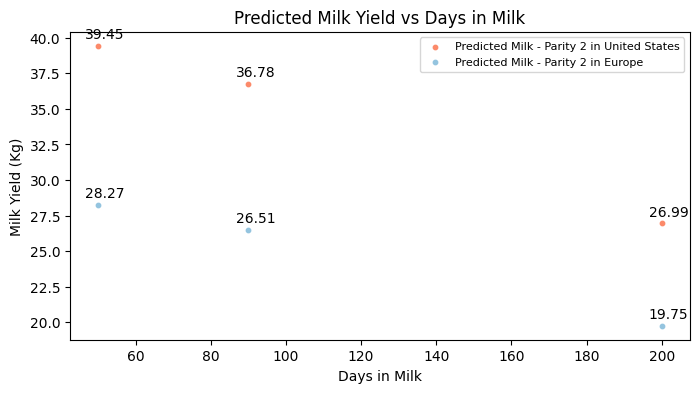

Trace(request_id=tr-74df813d9fe2422ba13b307ef510f776)

In [0]:
import mlflow

loaded_model = mlflow.langchain.load_model('models:/milkbot_visuals/2')

message = input("Your Question Input:")
payload = {"messages": [{"role": "user", "content": message}]}
response = loaded_model.invoke(payload)

In [0]:
from databricks_langchain import ChatDatabricks

milkbot_visuals= ChatDatabricks(endpoint="Milkbot_Visuals")



message = input("Your Question Input:")
# payload = {"messages": [{"role": "user", "content": message}]}
response = milkbot_visuals.invoke(message)
print(response)

Your Question Input: milk yield

Trace(request_id=tr-d070547989044b9bab413212ada85127)

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-6815787154151471>, line 9
      7 message = input("Your Question Input:")
      8 # payload = {"messages": [{"role": "user", "content": message}]}
----> 9 response = milkbot_visuals.invoke(message)
     10 print(response)

File /local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.12/site-packages/mlflow/utils/autologging_utils/safety.py:592, in safe_patch.<locals>.safe_patch_function(*args, **kwargs)
    590     patch_function.call(call_original, *args, **kwargs)
    591 else:
--> 592     patch_function(call_original, *args, **kwargs)
    594 session.state = "succeeded"
    596 try_log_autologging_event(
    597     AutologgingEventLogger.get_logger().log_patch_function_success,
    598     session,
   (...)
    602     kwargs,
    603 )

File /local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.12/